# 15. Cumulative Wins and League Overviews

Part of the `nuclearff` [User Tutorial](https://nolmacdonald.github.io/nuclearff/tutorial/index.html) notebook series -- every notebook shares one running `./demo` directory and depends on the ones before it having already run. See [README.md](README.md) for the full run order. Run `14_trade_network.ipynb` first.

Two more views built from the data `04_capturing_a_league.ipynb` and `03_sleeper_api.ipynb` already gave you: a manager's running win total over their entire real career, and a full snapshot of every league a Sleeper user belongs to. Mirrors the [Wins and Leagues](https://nolmacdonald.github.io/nuclearff/tutorial/15_wins_and_leagues.html) docs page.

## Cumulative wins

`weekly_results` derives each roster's per-week win/loss/tie from raw matchup points (nothing stores this directly), and `cumulative_wins` turns that into a running total per manager, in each manager's own chronological order:

In [1]:
from nuclearff.duckdb_io import read_table
from nuclearff.sleeper.wins import cumulative_wins, weekly_results

db_path = "./demo/data/cache/nuclearff.duckdb"
matchups = read_table(db_path, "sleeper_matchups")
standings = read_table(db_path, "sleeper_standings")

results = weekly_results(matchups)
cumulative = cumulative_wins(results, standings)
print(cumulative.columns)
print(f"{cumulative['manager'].n_unique()} managers")

['manager', 'season', 'week', 'game_number', 'cumulative_wins']
15 managers


`render_cumulative_wins` renders this as a step chart, one line per manager, ending in that manager's real Sleeper headshot rather than a text label. It needs each manager's avatar id -- pull it straight from `get_users`:

In [2]:
from nuclearff.report import render_cumulative_wins
from nuclearff.sleeper import SleeperClient

league_id = "1367225133634191360"
with SleeperClient(cache_dir="./demo/data/cache") as client:
    users = client.get_users(league_id)
avatar_ids = {u["display_name"]: u.get("avatar") for u in users}

written = render_cumulative_wins(
    cumulative,
    avatar_ids,
    "./demo/data/artifacts/wins.png",
    cache_dir="./demo/data/cache/avatars",
)
written

PosixPath('demo/data/artifacts/wins.png')

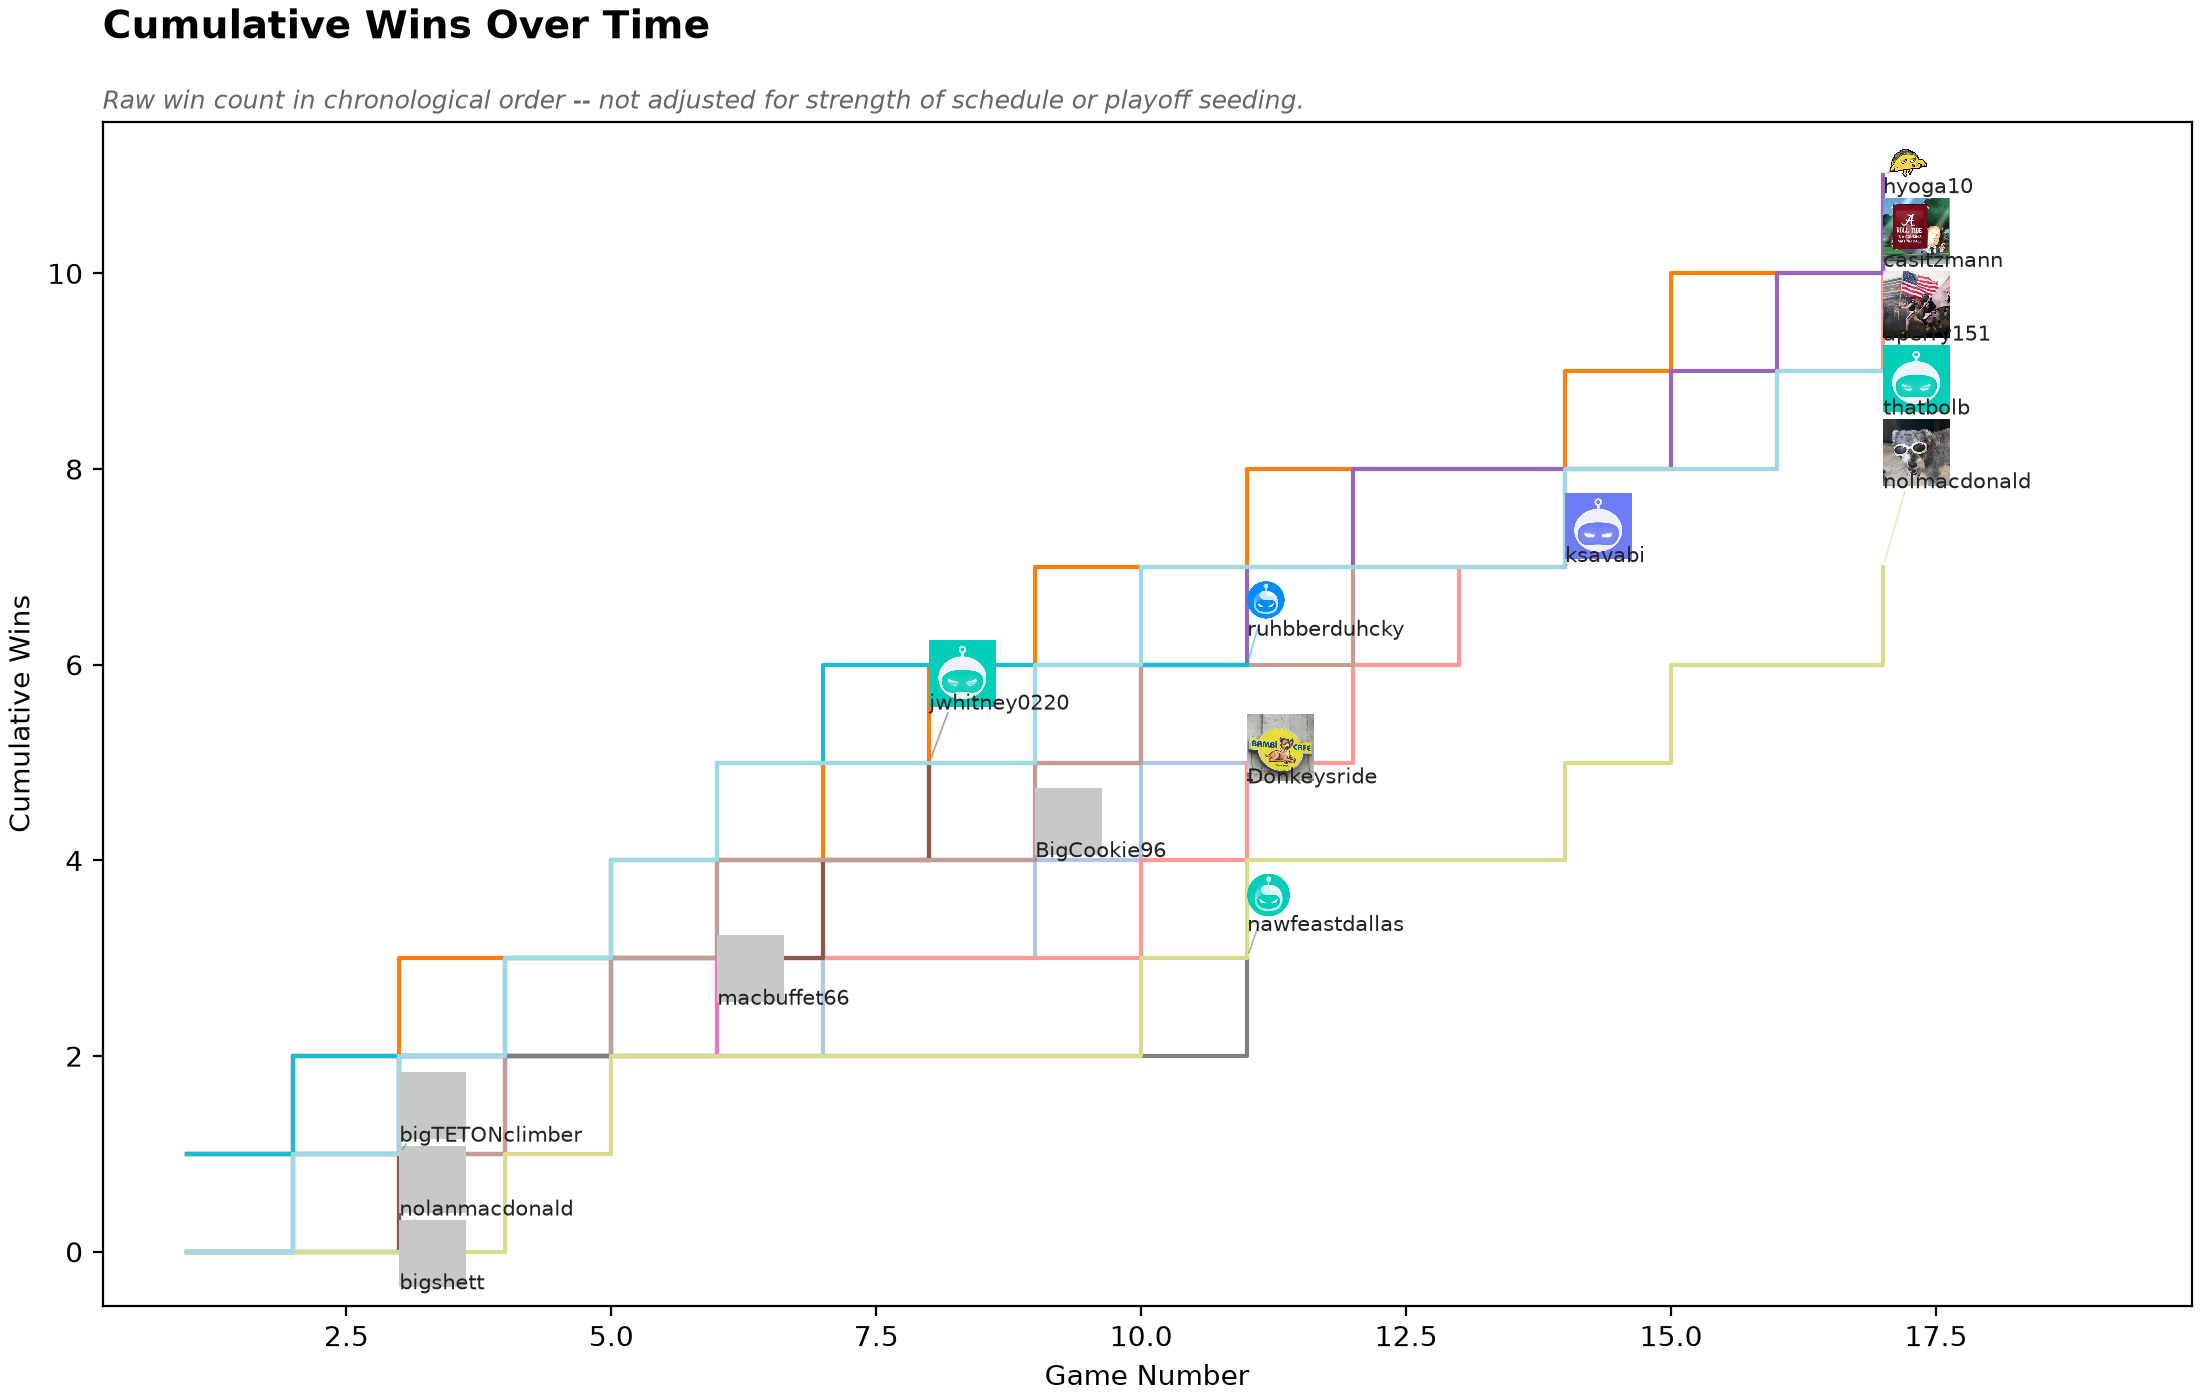

In [3]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/wins.png")
)  # Step chart of cumulative wins per manager, each line ending in a headshot

A manager's line starts at game 1 of *their own* real history, not the league's -- a manager who joined partway through doesn't get their earlier seasons backfilled. This is raw chronological win count, not adjusted for strength of schedule or playoff seeding -- recall from `04_capturing_a_league.ipynb` why that distinction matters here specifically: a real regular-season leader can still finish well outside first place. A manager missing from `avatar_ids` (or mapped to a failed download) renders with a neutral placeholder image rather than a broken one.

## A user's leagues, as a PNG table

`render_user_leagues_table` resolves a username to every league they're in for a season and renders it as a PNG table -- avatar, name, league id, type, team count, status:

In [4]:
from nuclearff.report import render_user_leagues_table, summarize_league_types

with SleeperClient(cache_dir="./demo/data/cache") as client:
    user = client.get_user("nolmacdonald")
    user_leagues = client.get_user_leagues(user["user_id"], 2026, sport="nfl")

written = render_user_leagues_table(
    user_leagues,
    "./demo/data/artifacts/user_leagues.png",
    title=f"{user['display_name']}'s Leagues",
    subtitle=f"{len(user_leagues)} leagues  |  nfl  |  2026",
    cache_dir="./demo/data/cache/avatars",
)
print(f"User:    {user['display_name']} ({user['user_id']})")
print(f"Leagues: {written}")

User:    nolmacdonald (332632476830679040)
Leagues: demo/data/artifacts/user_leagues.png


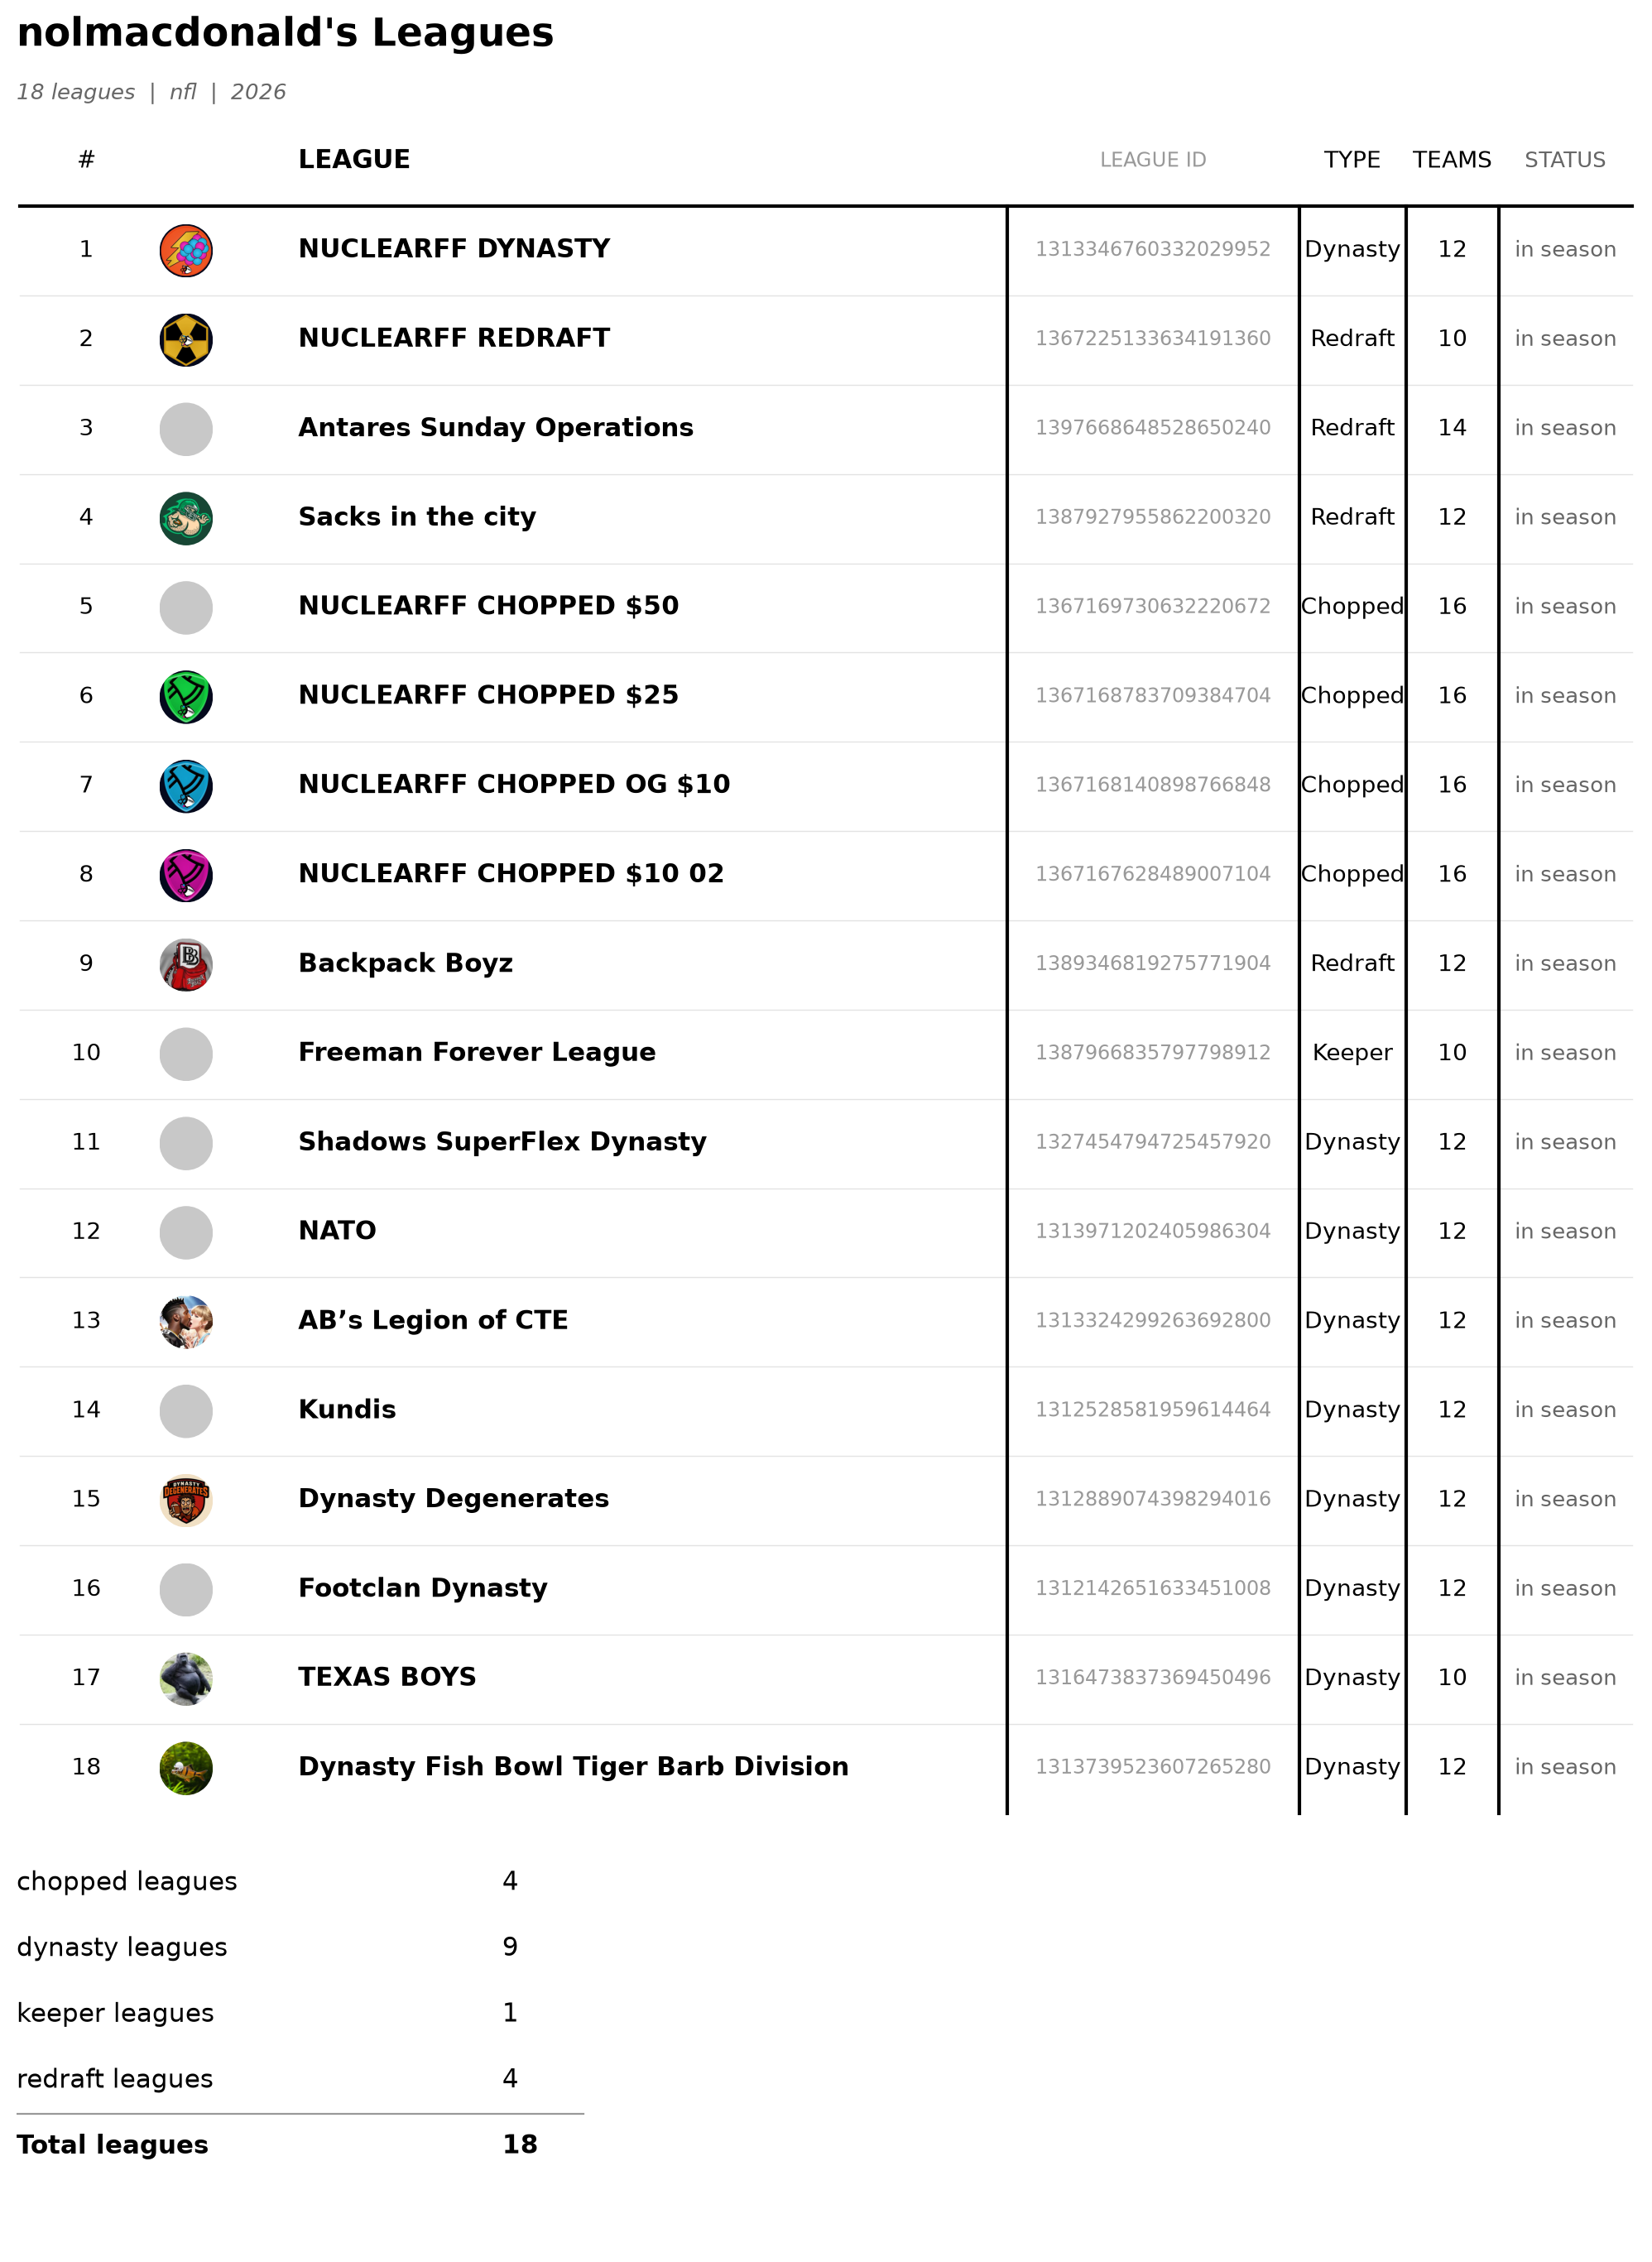

In [5]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/user_leagues.png")
)  # PNG table of a user's leagues with avatars and a per-type summary

`summarize_league_types` gives the same per-type breakdown the table's own bottom row shows, as a plain dict:

In [6]:
summarize_league_types(user_leagues)

{'chopped': 4, 'dynasty': 9, 'keeper': 1, 'redraft': 4, 'Total': 18}

`Type` resolves Sleeper's numeric `settings.type` (0/1/2/3) to a readable label from the league object itself, not a name-substring match -- a league can be genuinely Chopped-type without yet having eliminated anyone this season. A league with no avatar set gets a neutral placeholder image, not a broken cell.

## Actual vs. projected performance

One more comparison worth knowing about: `nuclearff.sleeper.performance` turns Sleeper's own weekly player projections (fetched with `fetch_and_write_projections_range`, scored under this league's rules) against real results, ranking who most over- or under-performed expectation:

In [7]:
from nuclearff.config import load_league_config
from nuclearff.ids import read_sleeper_players
from nuclearff.sleeper.performance import weekly_actuals, weekly_performance
from nuclearff.sleeper.projections import fetch_and_write_projections_range

league_cfg = load_league_config("./demo/configs/leagues/1367225133634191360.yaml")

with SleeperClient(cache_dir="./demo/data/cache") as client:
    fetch_and_write_projections_range(client, 2026, [1], db_path)

projections = read_table(db_path, "sleeper_projections")
players = read_sleeper_players(db_path)

actuals = weekly_actuals(matchups, standings, league_id, 1)
perf = weekly_performance(actuals, projections, players, league_cfg.scoring)
perf.sort("delta", descending=True).select(
    ["player_name", "position", "manager", "actual_points", "projected_points", "delta"]
).head(3)

player_name,position,manager,actual_points,projected_points,delta
str,str,str,f64,f64,f64
"""Jalen Coker""","""WR""","""jwhitney0220""",33.8,11.876,21.924
"""Caleb Williams""","""QB""","""thatbolb""",41.26,20.645,20.615
"""Kenneth Walker""","""RB""","""nawfeastdallas""",34.1,13.627,20.473


`starters_only=True` (the default) excludes bench players. Pass a whole season's worth of weeks through `season_actuals` and `season_summary` (which gates on `min_games` so one huge single-week delta can't dominate a season ranking) for the same comparison averaged across a season instead of one week. `render_weekly_performance_table` and `render_season_performance_table` render either as a styled PNG table.

> **Why this matters:** week 1 (or any very early week) of a season is the noisiest possible input for this comparison -- Sleeper's own projections haven't seen this season's real usage patterns yet, and a huge single-week delta is as likely to be projection error as it is real over/underperformance. Treat a single-week `report performance` the way this notebook's own numbers should be read: as "what happened this week," not "who is actually good" -- `season_summary`'s `min_games` floor exists specifically to protect the season-long version of this question from that same noise.

## What's Next

This closes out the feature tour. `16_draft_companion_tools.ipynb` covers two smaller, newer library functions still under active development, and `17_querying_and_provenance.ipynb` ties everything in this tutorial back together -- one shared database, and how to record exactly how a dataset was built.

## See Also

- `13_league_history.ipynb` -- `weekly_results`, reused there for win/loss streaks.
- [Wins and Leagues](https://nolmacdonald.github.io/nuclearff/tutorial/15_wins_and_leagues.html) -- the matching docs page.